In [1]:

!pip install torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
batch_size = 128
latent_dim = 32
epochs = 5
learning_rate = 1e-3

In [3]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 63.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.76MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.73MB/s]


In [4]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        z = self.encoder(x)
        out = self.decoder(z)
        return out

model = Autoencoder(latent_dim).to(device)

In [5]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [6]:
for epoch in range(epochs):
    total_loss = 0

    for images, _ in train_loader:
        images = images.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, images.view(images.size(0), -1))

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")

Epoch [1/5], Loss: 0.0497
Epoch [2/5], Loss: 0.0215
Epoch [3/5], Loss: 0.0159
Epoch [4/5], Loss: 0.0133
Epoch [5/5], Loss: 0.0118


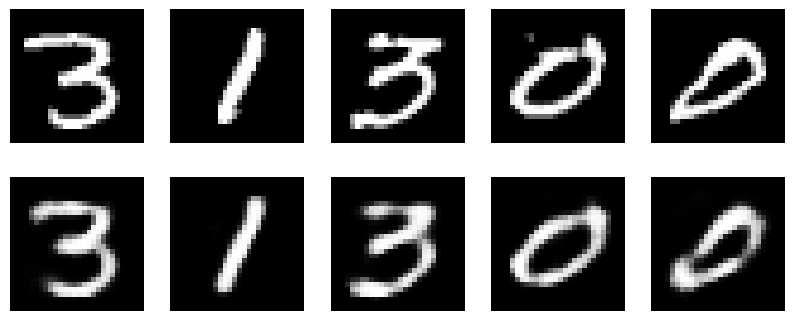

In [7]:
model.eval()

with torch.no_grad():
    images, _ = next(iter(train_loader))
    images = images.to(device)
    outputs = model(images)

# Move to CPU for plotting
images = images.cpu()
outputs = outputs.cpu()

plt.figure(figsize=(10,4))

# Original images
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i].view(28,28), cmap='gray')
    plt.axis('off')

# Reconstructed images
for i in range(5):
    plt.subplot(2,5,i+6)
    plt.imshow(outputs[i].view(28,28), cmap='gray')
    plt.axis('off')

plt.show()